# Model Spikey-like objects observed by *Plato* with JAXNS

In this notebook we use the Bayesian inference package `JAXNS`, using nested sampling, to model the Spikey-like objects observed by *Plato*.

In [5]:
%load_ext autoreload
%autoreload 2
# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# Built-in
import os
import sys
import json
import copy
import warnings

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from jax import numpy as jnp
import numpyro
import numpyro.distributions as dist

# Select number of CPUs
numpyro.enable_x64()
numpyro.set_host_device_count(6)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

In [3]:
# Hide warnings
warnings.filterwarnings("ignore")

In [4]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
fdir = path / 'figures'
cv = 'tomato'
cm = 'orange'
c0 = 'lightseagreen'
c1 = 'mediumorchid'

---
## 1. *Plato* 2-yr light curve with $P = 16$
---

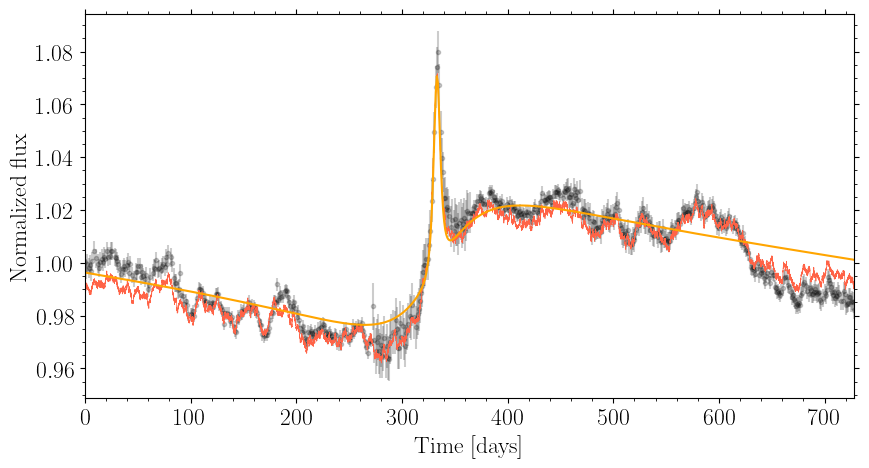

In [20]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_feather(ddir / 'lc_spikey_plato_mag16.ftr')
dv = pd.read_feather(ddir / 'lc_spikey_plato_template.ftr')
Q0=9

# Bin to 1-hour light curve 
df = ut.bin_lc(df, bin_size=1)

# Cut light curve to 2-year duration
df = df[df.time < 4*ut.year2day()]

# Generate relativistic Spikey model
params = smbhb.model_params()
params.t0    = 0.712
params.sigma = 0 
model = smbhb.model(params)
dm = model.light_curve(df.time.to_numpy(), df=True)

# Reset time arrays
t0 = df.time.iloc[0]
df.time -= t0
dv.time -= t0
dm.time -= t0

# Secure zero mean level flux
df.flux -= (np.mean(df.flux) - 1)
time = df.time.to_numpy()
flux = df.flux.to_numpy()

# Load default model priors
priors_DM  = bs.model_priors(params, model='DM') 
priors_Q   = bs.model_priors(params, model='Q',   flux=flux) 
priors_QDM = bs.model_priors(params, model='QDM', flux=flux) 

# Plot light curve
fig, ax = pt.plot_lc(df, dv, cm=cv, lw=0.5)
ax.plot(dm.time, dm.flux, '-', c=cm);

---
### 1.1. Model Q
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 7340791
samples: 31062
phantom samples: 0
likelihood evals / sample: 236.3
phantom fraction (%): 0.0%
--------
logZ=2701.356 +- 0.065
max(logL)=2708.384
H=-5.75
ESS=2969
--------
mean: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
mean: 0.996 +- 0.015 | 0.979 / 0.997 / 1.013 | 0.997 | 0.997
--------
sigma: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
sigma: 0.0201 +- 0.0056 | 0.0143 / 0.019 / 0.0274 | 0.0172 | 0.0172
--------
tau: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
tau: 290.0 +- 180.0 | 130.0 / 240.0 / 490.0 | 200.0 | 200.0
--------
CPU times: user 1h 6min 26s, sys: 5min 7s, total: 1h 11min 33s
Wall time: 30min 31s
```

In [23]:
filename = rdir / 'spikey_plato_jaxns_2yr24h16mag_Q.npy'

In [21]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors_Q, 
#     build_mean=None, 
#     build_kernel=bs.drw_kernel, 
#     ofile=filename
# )

In [24]:
result = ut.load_result(filename)

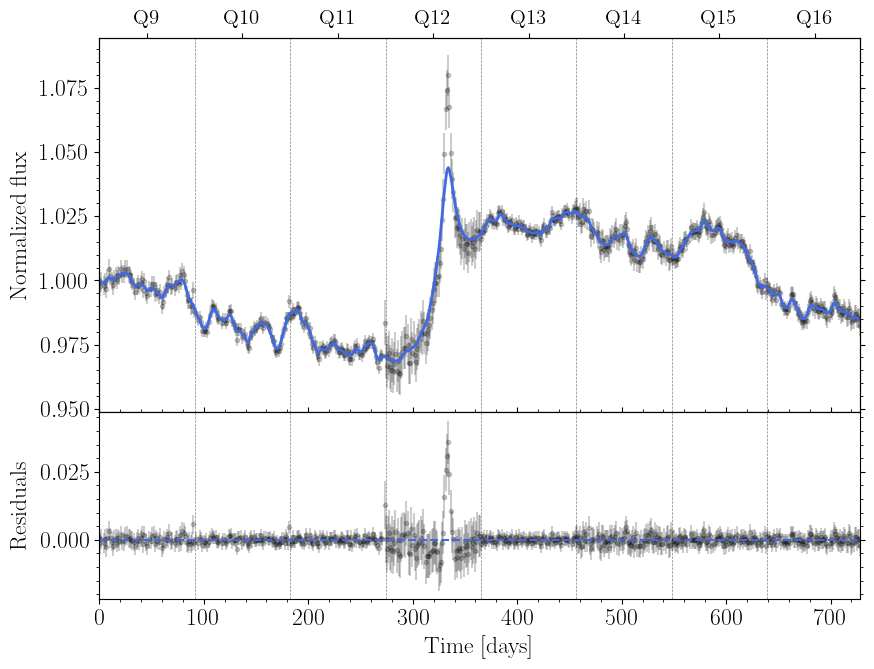

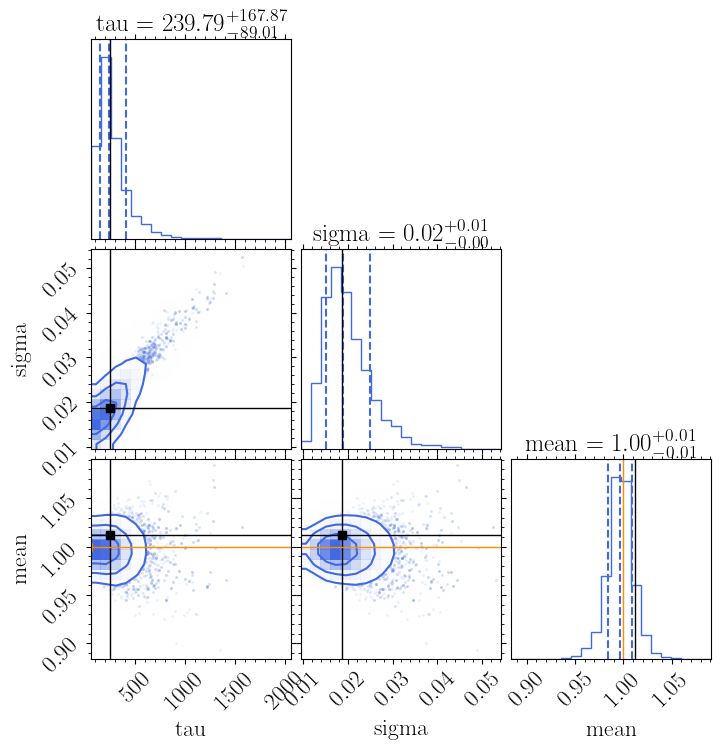

In [25]:
# Show results
dm = bs.model_lightcurve_drw(time, result)
fig, ax = pt.plot_result(df, dm, Q0=Q0)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [26]:
# Print percentiles for latex
ut.get_percentiles(result, latex=True);

tau : pmx { 239.79497 }{ -89.01241 }{ 167.87168 }
sigma : pmx { 0.01898 }{ -0.00392 }{ 0.00590 }
mean : pmx { 0.99680 }{ -0.01273 }{ 0.01207 }


---
### 1.2. Model DM
```
```

In [27]:
filename = rdir / 'spikey_plato_jaxns_2yr24h16mag_DM.npy'

In [ ]:
%%time
result = bs.run_jaxns(
    df, params, priors_DM, 
    build_mean=bs.smbhb_mean_builder,
    build_kernel=None, 
    ofile=filename
)

INFO:jaxns:Number of Markov-chains set to: 2000


Running over 6 devices.


In [ ]:
result = ut.load_result(filename)

In [ ]:
# Show results
dm = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, Q0=Q0)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [ ]:
# Resolve bimodality in t0
clusters_t = bs.get_posterior_clusters(df, result, param_cluster='t0', n_components=2)
result_t0 = clusters_t[0]
result_t1 = clusters_t[1]
fig = pt.plot_corner(result_t0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_t1, best_params='mle', true_params=True, color=c1);

In [ ]:
# Resolve bimodality in w
clusters_w = bs.get_posterior_clusters(df, result_t0, param_cluster='w', n_components=2)
result_w0 = clusters_w[0]
result_w1 = clusters_w[1]
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1);

In [ ]:
# Print percentiles for latex
ut.get_percentiles(result_w0, latex=True);

---
### 1.3. Model QDM
```
```

In [ ]:
filename = rdir / 'spikey_plato_jaxns_2yr24h_QDM.npy'

In [ ]:
%%time 
result = bs.run_jaxns(
    df, params, priors_QDM, 
    build_mean=bs.smbhb_mean_builder, 
    build_kernel=bs.drw_kernel, 
    ofile=filename
)

In [ ]:
result = ut.load_result(filename)

In [ ]:
# Show results
dm_QDM = bs.model_lightcurve_drw(time, result)
dm_DM = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm_QDM, Q0=Q0)
ax[0].plot(dm_DM.time, dm_DM.flux, c=c0, lw=2)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [ ]:
# Resolve bimodality in t0
clusters_t = bs.get_posterior_clusters(df, result, param_cluster='t0', n_components=2)
result_t0 = clusters_t[0]
result_t1 = clusters_t[1]
fig = pt.plot_corner(result_t0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_t1, best_params='mle', true_params=True, color=c1);

In [ ]:
# Resolve bimodality in w
clusters_w = bs.get_posterior_clusters(df, result_t0, param_cluster='w', n_components=2)
result_w0 = clusters_w[0]
result_w1 = clusters_w[1]
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0);
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1);

In [ ]:
# Print percentiles for latex
ut.get_percentiles(result_w0, latex=True);

---
## 2. *Plato* 4-yr light curve
---